In [1]:
import pandas as pd

path = "/home/madhav/workstation/Lab/DataSet/Preprocessing1.csv"
df = pd.read_csv(path)

df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,WeekDay,Day
0,Jet Airways,Delhi,Banglore,DEL → BOM → COK,20:00,04:25 10 Jun,26h 35m,1 stop,In-flight meal not included,14924,6,Thursday,6.0
1,Jet Airways,Delhi,Cochin,DEL → BOM → COK,16:00,19:00 10 Jun,27h,1 stop,In-flight meal not included,10577,6,Sunday,9.0
2,Jet Airways,Mumbai,Hyderabad,BOM → HYD,19:35,21:05,1h 30m,non-stop,No info,5678,3,Friday,15.0
3,Multiple carriers,Delhi,Banglore,DEL → BOM → COK,18:55,01:30 16 Jun,15h 10m,1 stop,In-flight meal not included,7408,5,Monday,6.0
4,Air India,Delhi,Cochin,DEL → COK,17:10,17:55,8h 20m,non-stop,No info,6724,6,Monday,24.0


In [10]:
# foundational Statistics of dataset with pandas

print(df.shape)
print(df.columns)
print("Flight description :", df.describe())

df.head, df.shape, df.columns

(9450, 13)
Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Month',
       'WeekDay', 'Day'],
      dtype='str')
Flight description :               Price        Month          Day
count   9450.000000  9450.000000  9214.000000
mean    9027.895556     4.718730    13.517582
std     4466.677471     1.162725     8.459792
min     1759.000000     3.000000     1.000000
25%     5198.000000     3.000000     6.000000
50%     8366.000000     5.000000    12.000000
75%    12373.000000     6.000000    21.000000
max    57209.000000     6.000000    27.000000


(<bound method NDFrame.head of                 Airline    Source Destination                        Route  \
 0           Jet Airways     Delhi    Banglore              DEL → BOM → COK   
 1           Jet Airways     Delhi      Cochin              DEL → BOM → COK   
 2           Jet Airways    Mumbai   Hyderabad                    BOM → HYD   
 3     Multiple carriers     Delhi    Banglore              DEL → BOM → COK   
 4             Air India     Delhi      Cochin                    DEL → COK   
 ...                 ...       ...         ...                          ...   
 9445          Air India  Banglore      Cochin              BLR → MAA → DEL   
 9446             IndiGo     Delhi      Cochin              DEL → BOM → COK   
 9447  Multiple carriers     Delhi      Cochin              DEL → BOM → COK   
 9448        Jet Airways   Kolkata    Banglore              CCU → BOM → BLR   
 9449          Air India   Kolkata    Banglore  CCU → GAU → IMF → DEL → BLR   
 
      Dep_Time  Arri

<BarContainer object of 7 artists>

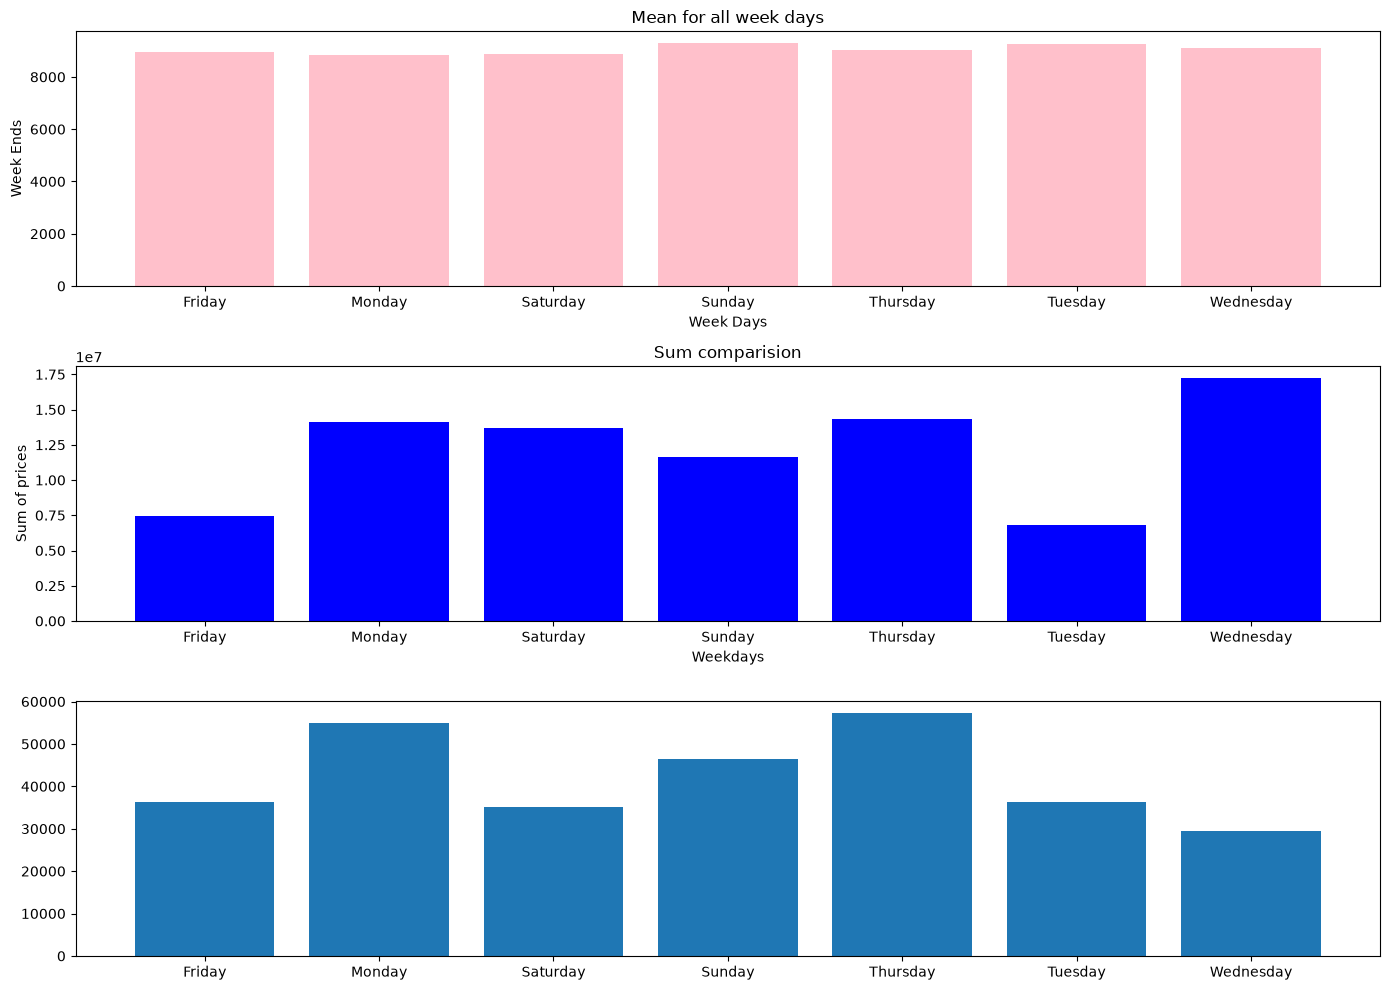

In [118]:
mean = df.groupby("WeekDay")["Price"].mean() # All week days average

import matplotlib.pyplot as plt

x = mean.index
y = mean

fig, axs = plt.subplots(3,1, figsize=(14,10),layout="tight")


# Ploting first mean graph
axs[0].bar(x,y, color="pink")
axs[0].set(
    title="Mean for all week days", 
    xlabel="Week Days",
    ylabel="Week Ends"
)

sumed = df.groupby("WeekDay")["Price"].sum()

y2 = sumed
axs[1].bar(x,y2, color="blue")
axs[1].set(
    title="Sum comparision",
    xlabel="Weekdays",
    ylabel="Sum of prices"
)

info = df.groupby("WeekDay")["Price"].max()

y3 = info
axs[2].bar(x, y3)



In [119]:
# Flight ticket price average 

series = df["Price"]

total_sum = series.sum()
length = series.shape[0]
avg = total_sum/length

print(length)
print(f"Average of the total flight Price : {avg}")

9450
Average of the total flight Price : 9027.895555555555


<BarContainer object of 9450 artists>

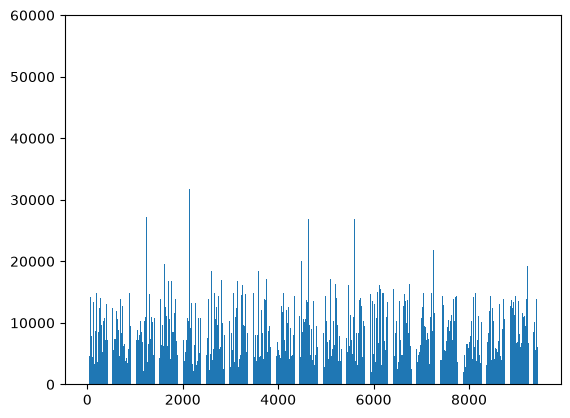

In [120]:
# Validating the pice analogy
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(0, length)
y = series

plt.bar(X,y)

<class 'pandas.Series'> Month
5    3092
6    3044
3    2388
4     926
Name: count, dtype: int64


<BarContainer object of 4 artists>

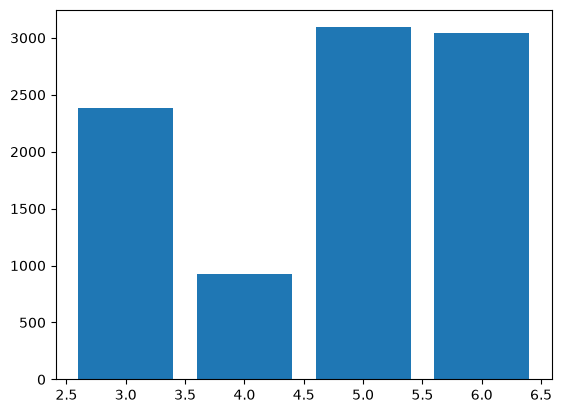

In [121]:
# Which month had highiest number of flights
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

'''
To compute the total flights flyed in a month
we can segrigate the frequency of each month and plot into bar graph

Either the pythonic way or with pandas way of using segrigation
'''

flights_data = df["Month"].value_counts()

print(type(flights_data), flights_data)
x = flights_data.index
y = flights_data

plt.bar(x,y)

In [6]:
# Average flights comparision with weekdays and weekends
import numpy as np

fetch = [df["Price"], df["WeekDay"]]

weekend_series = []
weekday_series = []
for price, day in zip(df["Price"], df["WeekDay"]):
    if (day == "Sunday")or(day == "Saturday"):
        weekend_series.append(price)
    else:
        weekday_series.append(price)

# Average out both elemns
s1 = np.array(weekday_series)
s2 = np.array(weekend_series)
price1 =  np.sum(s1) / len(weekday_series)
price2 = np.sum(s2) / len(weekend_series)

print(price1, price2)

9015.219666215608 9058.016077170418


# Foundations with pandas data insighting workflow



[Text(0.5, 1.0, 'Age Distribution'),
 Text(0.5, 0, 'Age group'),
 Text(0, 0.5, 'Number of people')]

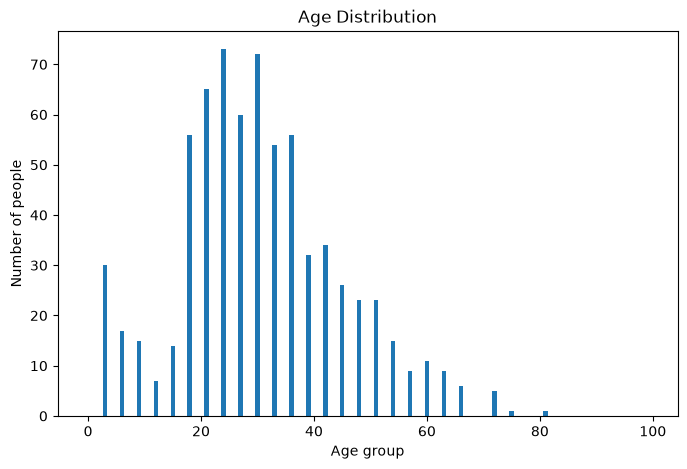

In [7]:
#@title Foundational Data Exploration tutorial cook book
import pandas as pd
import numpy as np

path = "/home/madhav/workstation/Lab/DataSet/titanic.csv"
titanic = pd.read_csv(path)

# Making basic filteration with the dataset
age_filter = titanic[ titanic["Age"] < 2 ] # new data frame created ? or just the view ?

age_info = titanic["Age"]
age_buckets = np.arange(0,101, 3)

# ranging for finding the people with this group ages
age_info_dict = {}

prev = -1  # Logical Error of starting with zero
for cap in age_buckets:
    age_info_dict[cap] = len(titanic[(age_buckets[prev] < age_info) & (age_info <= cap)]["Age"].values)
    prev+=1
    
# Working for extracting the age information for the plot

x = age_info_dict.keys()
y = age_info_dict.values()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x,y)
ax.set(
    title="Age Distribution",
    xlabel="Age group",
    ylabel="Number of people"
      )

[Text(0.5, 1.0, 'Prices Chart for all Airlines'),
 Text(0.5, 0, 'Air Line Names'),
 Text(0, 0.5, 'Price Graph')]

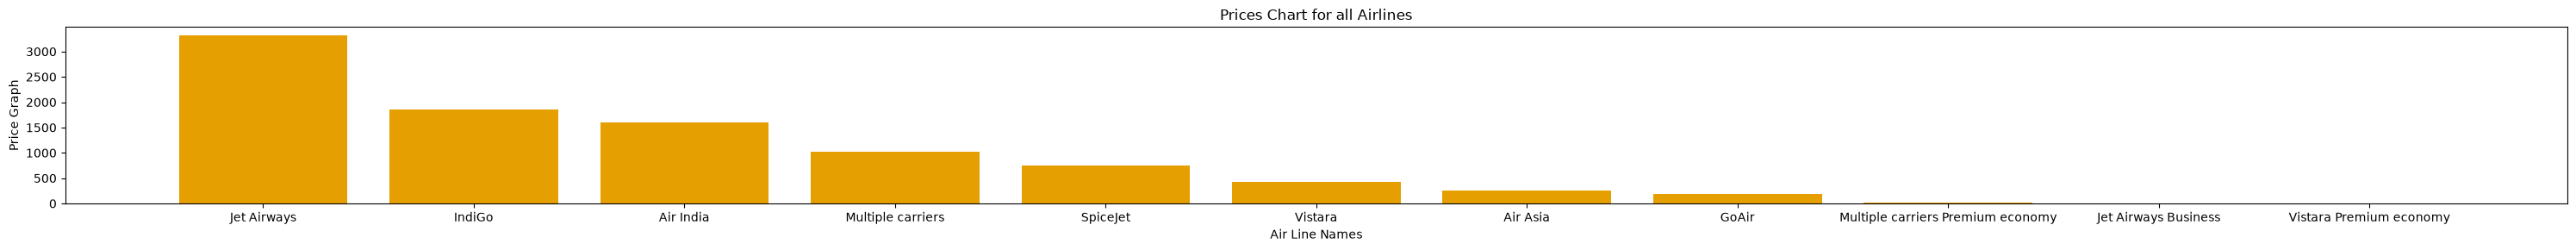

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/madhav/workstation/Lab/DataSet/Preprocessing1.csv"
df = pd.read_csv(path)

info = df.loc[df.Price > 1000, "Airline"].value_counts()
x = info.index
y = info

fig,ax = plt.subplots(figsize=(30,3), layout="tight")

ax.bar(x,y, color="#E69F00")
ax.set(
    title="Prices Chart for all Airlines",
    xlabel="Air Line Names",
    ylabel="Price Graph"
)